# Strategy Evaluation

This notebook presents the formal evaluation of three rule-based trading strategies: **Moving Average Crossover**, **RSI Threshold**, and **Volatility Breakout**. Each strategy is evaluated on four datasets: EURUSD 15min, EURUSD 1H, GBPUSD 15min, and GBPUSD 1H. Evaluation covers directional accuracy, precision, recall, F1 score, computational FLOPs, and signal generation latency.

---
## Section 1 — Setup

The FX project root is added to `sys.path` so that `config.py` and all strategy modules can be imported from this notebook.

In [ ]:
import sys
import os


try:
    import google.colab
    IN_COLAB = os.path.isdir("/content")
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = "/content/drive/My Drive/FX"
else:
    # Works whether kernel starts in notebooks/ (Jupyter) or FX/ (VSCode)
    _cwd = os.path.abspath(os.getcwd())
    ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == "notebooks" else _cwd

if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from config import (
    PROCESSED_DIR, SPLITS_DIR, TABLES_DIR, FIGURES_DIR,
    TRAIN_RATIO, VAL_RATIO, TEST_RATIO,
    SIGNIFICANCE_THRESHOLD,
    FLOPS_MA, FLOPS_RSI, FLOPS_VB,
)

from strategies.ma_crossover        import evaluate as evaluate_ma
from strategies.rsi_threshold       import evaluate as evaluate_rsi
from strategies.volatility_breakout import evaluate as evaluate_vb

plt.style.use("seaborn-v0_8")
pd.set_option("display.float_format", "{:.4f}".format)

env = "Google Colab" if IN_COLAB else "Local"
print(f"Setup complete. Environment: {env}")
print(f"Project root: {ROOT}")

Mounted at /content/drive
Setup complete. Environment: Google Colab
Project root: /content/drive/My Drive/FX


---
## Section 2 — Load Processed Datasets

The four feature-engineered datasets produced in `preliminary_analysis.ipynb` are loaded directly from `data/processed/`. Each file contains OHLCV data, all ten computed features, and the binary `Target` column. The chronological test-set index is then derived from each dataset using the same **70 / 15 / 15** train–validation–test ratios defined in `config.py`, ensuring the test window is identical to the one used during model training.

In [2]:
# Load all four processed datasets from data/processed/
file_map = {
    'EURUSD 15min': 'EURUSD_15min.csv',
    'EURUSD 1H':    'EURUSD_1h.csv',
    'GBPUSD 15min': 'GBPUSD_15min.csv',
    'GBPUSD 1H':    'GBPUSD_1h.csv',
}

datasets = {}
for name, filename in file_map.items():
    path = os.path.join(PROCESSED_DIR, filename)
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index = pd.to_datetime(df.index, errors='coerce')
    df = df[df.index.notna()]
    datasets[name] = df
    print(f'{name}: {df.shape}  |  {df.index.min().date()} → {df.index.max().date()}')

EURUSD 15min: (114008, 11)  |  2020-01-02 → 2024-12-31
EURUSD 1H: (29156, 11)  |  2020-01-06 → 2024-12-31
GBPUSD 15min: (113944, 11)  |  2020-01-02 → 2024-12-31
GBPUSD 1H: (29141, 11)  |  2020-01-06 → 2024-12-31


In [3]:
# Derive test-set indices using the same chronological 70/15/15 split
test_indices = {}
for name, df in datasets.items():
    n       = len(df)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    test_start = n_train + n_val
    test_idx   = df.index[test_start:]
    test_indices[name] = test_idx
    print(f'{name}: test starts {test_idx.min().date()}  |  {len(test_idx):,} bars')

EURUSD 15min: test starts 2024-04-08  |  17,102 bars
EURUSD 1H: test starts 2024-04-03  |  4,374 bars
GBPUSD 15min: test starts 2024-04-08  |  17,093 bars
GBPUSD 1H: test starts 2024-04-03  |  4,372 bars


---
## Section 3 — Moving Average Crossover Evaluation

The Moving Average Crossover strategy generates a directional signal at **every bar** — there are no neutral periods. A buy signal (+1) is issued when the 10-period SMA lies above the 50-period SMA; a sell signal (−1) is issued otherwise. Because every bar receives a signal, accuracy is computed over the full test set without any exclusions.

In [4]:
# Run MA Crossover evaluation on all four datasets
ma_results = {}
for name, df in datasets.items():
    ma_results[name] = evaluate_ma(df, test_indices[name])
    print(f'  {name}: done  (accuracy={ma_results[name]["accuracy"]:.4f})')

  EURUSD 15min: done  (accuracy=0.5095)
  EURUSD 1H: done  (accuracy=0.5089)
  GBPUSD 15min: done  (accuracy=0.5058)
  GBPUSD 1H: done  (accuracy=0.5039)


In [5]:
# MA Crossover — accuracy metrics table
ma_rows = []
for name, r in ma_results.items():
    ma_rows.append({
        'Dataset':   name,
        'Accuracy':  f"{r['accuracy']*100:.2f}%",
        'Precision': f"{r['precision']*100:.2f}%",
        'Recall':    f"{r['recall']*100:.2f}%",
        'F1':        f"{r['f1']*100:.2f}%",
        'N Signals': r['n_signals'],
    })
ma_table = pd.DataFrame(ma_rows).set_index('Dataset')
print('MA Crossover — Accuracy Metrics')
display(ma_table)

MA Crossover — Accuracy Metrics


,Accuracy,Precision,Recall,F1,N Signals
Dataset,,,,,
EURUSD 15min,50.95%,51.00%,50.95%,50.96%,17102
EURUSD 1H,50.89%,50.90%,50.89%,50.89%,4374
GBPUSD 15min,50.58%,50.63%,50.58%,50.55%,17093
GBPUSD 1H,50.39%,50.44%,50.39%,50.35%,4372


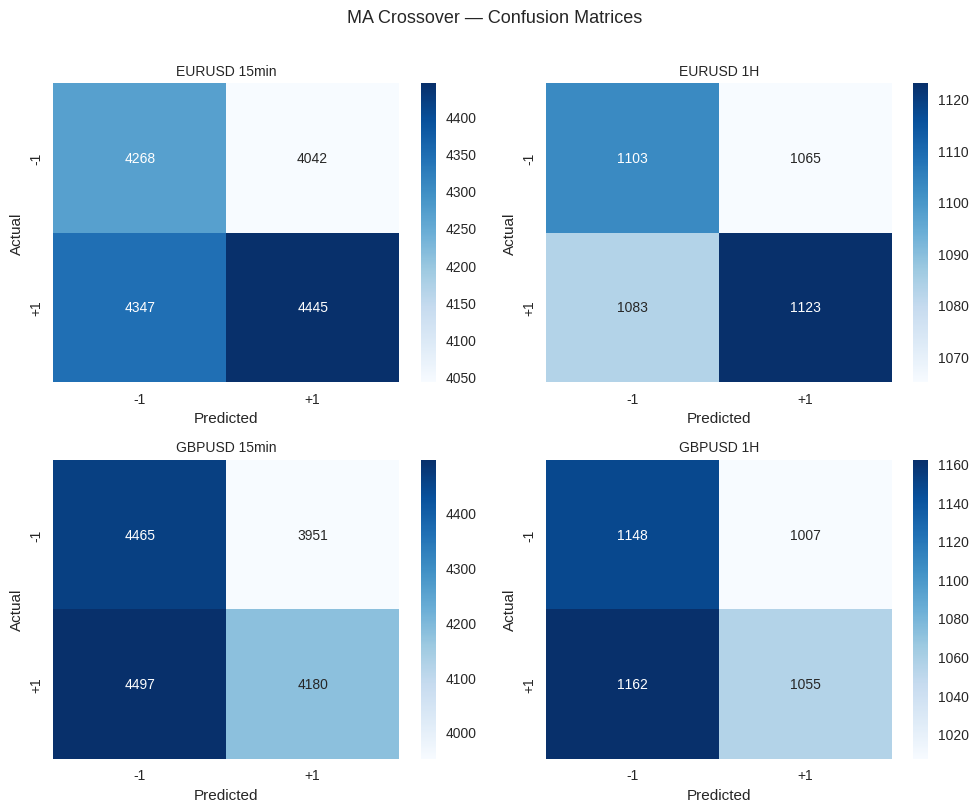

Saved: ma_confusion_matrices.png


In [6]:
# MA Crossover — confusion matrices (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (name, r) in zip(axes.flat, ma_results.items()):
    cm = r['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['-1', '+1'], yticklabels=['-1', '+1'])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
fig.suptitle('MA Crossover — Confusion Matrices', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'ma_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ma_confusion_matrices.png')

In [7]:
# MA Crossover — computational metrics (same across all datasets)
sample_ma = next(iter(ma_results.values()))
print('MA Crossover — Computational Metrics')
print(f"  FLOPs per evaluation : {sample_ma['flops']:,}")
print(f"  Mean latency         : {sample_ma['latency_us']:.4f} µs")

MA Crossover — Computational Metrics
  FLOPs per evaluation : 123
  Mean latency         : 0.0118 µs


---
## Section 4 — RSI Threshold Evaluation

The RSI Threshold strategy generates active signals only when the 14-period RSI falls **below 30** (oversold — buy) or rises **above 70** (overbought — sell). Bars where RSI lies between these thresholds produce a neutral signal (0) and are excluded from accuracy evaluation, since the strategy abstains from taking a position. Accuracy is therefore computed only over bars where the strategy commits to a direction, and the proportion of active vs. neutral bars is reported for each dataset.

In [8]:
# Run RSI Threshold evaluation on all four datasets
rsi_results = {}
for name, df in datasets.items():
    rsi_results[name] = evaluate_rsi(df, test_indices[name])
    print(f'  {name}: done  (accuracy={rsi_results[name]["accuracy"]:.4f}, '
          f'active={rsi_results[name]["n_signals"]:,}, '
          f'neutral={rsi_results[name]["n_neutral"]:,})')

  EURUSD 15min: done  (accuracy=0.5210, active=1,474, neutral=15,628)
  EURUSD 1H: done  (accuracy=0.5230, active=499, neutral=3,875)
  GBPUSD 15min: done  (accuracy=0.5132, active=1,592, neutral=15,501)
  GBPUSD 1H: done  (accuracy=0.5241, active=580, neutral=3,792)


In [9]:
# RSI Threshold — accuracy metrics table
rsi_rows = []
for name, r in rsi_results.items():
    total = r['n_signals'] + r['n_neutral']
    rsi_rows.append({
        'Dataset':            name,
        'Accuracy':           f"{r['accuracy']*100:.2f}%",
        'Precision':          f"{r['precision']*100:.2f}%",
        'Recall':             f"{r['recall']*100:.2f}%",
        'F1':                 f"{r['f1']*100:.2f}%",
        'N Active Signals':   r['n_signals'],
        'N Neutral Excluded': r['n_neutral'],
        'Active Signal %':    f"{r['n_signals']/total*100:.1f}%" if total > 0 else 'N/A',
    })
rsi_table = pd.DataFrame(rsi_rows).set_index('Dataset')
print('RSI Threshold — Accuracy Metrics')
display(rsi_table)

RSI Threshold — Accuracy Metrics


,Accuracy,Precision,Recall,F1,N Active Signals,N Neutral Excluded,Active Signal %
Dataset,,,,,,,
EURUSD 15min,52.10%,52.18%,52.10%,52.10%,1474,15628,8.6%
EURUSD 1H,52.30%,52.30%,52.30%,52.30%,499,3875,11.4%
GBPUSD 15min,51.32%,51.35%,51.32%,51.32%,1592,15501,9.3%
GBPUSD 1H,52.41%,52.44%,52.41%,52.40%,580,3792,13.3%


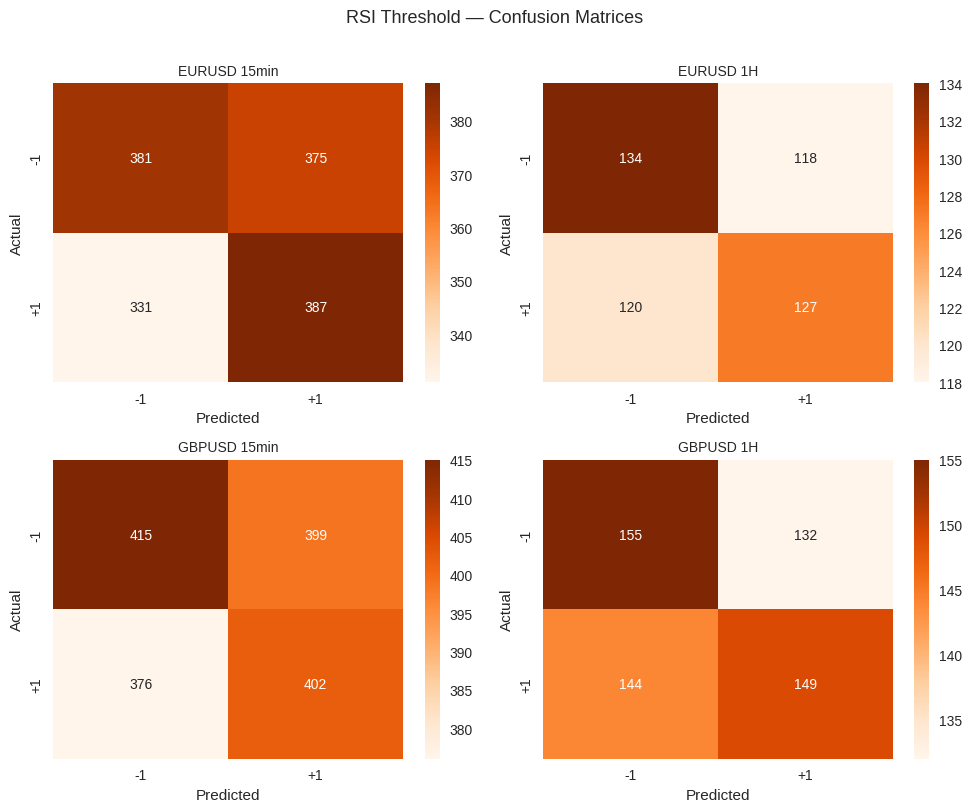

Saved: rsi_confusion_matrices.png


In [10]:
# RSI Threshold — confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (name, r) in zip(axes.flat, rsi_results.items()):
    cm = r['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
                xticklabels=['-1', '+1'], yticklabels=['-1', '+1'])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
fig.suptitle('RSI Threshold — Confusion Matrices', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'rsi_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: rsi_confusion_matrices.png')

In [11]:
# RSI Threshold — computational metrics
sample_rsi = next(iter(rsi_results.values()))
print('RSI Threshold — Computational Metrics')
print(f"  FLOPs per evaluation : {sample_rsi['flops']:,}")
print(f"  Mean latency         : {sample_rsi['latency_us']:.4f} µs")

RSI Threshold — Computational Metrics
  FLOPs per evaluation : 68
  Mean latency         : 0.0950 µs


---
## Section 5 — Volatility Breakout Evaluation

The Volatility Breakout strategy operates in mean reversion mode: a buy signal (+1) is issued when the closing price falls below the 20-period Donchian lower band, anticipating a bounce upward; a sell signal (-1) is issued when price  rises above the upper band, anticipating a reversal downward. This mean reversion formulation was adopted following empirical testing which confirmed that the 2024 test period exhibits mean reverting rather than trendingbehaviour at breakout points. Bars where price remains within the channel produce a neutral signal (0) and are excluded from accuracy evaluation.

In [12]:
# Run Volatility Breakout evaluation on all four datasets
vb_results = {}
for name, df in datasets.items():
    vb_results[name] = evaluate_vb(df, test_indices[name])
    print(f'  {name}: done  (accuracy={vb_results[name]["accuracy"]:.4f}, '
          f'active={vb_results[name]["n_signals"]:,}, '
          f'neutral={vb_results[name]["n_neutral"]:,})')

  VB signal distribution:  +1=6,561   0=100,720  -1=6,727
  EURUSD 15min: done  (accuracy=0.5291, active=2,030, neutral=15,072)
  VB signal distribution:  +1=1,640   0=25,910  -1=1,606
  EURUSD 1H: done  (accuracy=0.5130, active=462, neutral=3,912)
  VB signal distribution:  +1=6,574   0=100,567  -1=6,803
  GBPUSD 15min: done  (accuracy=0.5361, active=2,009, neutral=15,084)
  VB signal distribution:  +1=1,635   0=25,781  -1=1,725
  GBPUSD 1H: done  (accuracy=0.5300, active=483, neutral=3,889)


In [13]:
# Volatility Breakout — accuracy metrics table
vb_rows = []
for name, r in vb_results.items():
    total = r['n_signals'] + r['n_neutral']
    vb_rows.append({
        'Dataset':            name,
        'Accuracy':           f"{r['accuracy']*100:.2f}%",
        'Precision':          f"{r['precision']*100:.2f}%",
        'Recall':             f"{r['recall']*100:.2f}%",
        'F1':                 f"{r['f1']*100:.2f}%",
        'N Active Signals':   r['n_signals'],
        'N Neutral Excluded': r['n_neutral'],
        'Active Signal %':    f"{r['n_signals']/total*100:.1f}%" if total > 0 else 'N/A',
    })
vb_table = pd.DataFrame(vb_rows).set_index('Dataset')
print('Volatility Breakout — Accuracy Metrics')
display(vb_table)

Volatility Breakout — Accuracy Metrics


,Accuracy,Precision,Recall,F1,N Active Signals,N Neutral Excluded,Active Signal %
Dataset,,,,,,,
EURUSD 15min,52.91%,52.90%,52.91%,52.90%,2030,15072,11.9%
EURUSD 1H,51.30%,51.35%,51.30%,51.30%,462,3912,10.6%
GBPUSD 15min,53.61%,53.60%,53.61%,53.57%,2009,15084,11.8%
GBPUSD 1H,53.00%,53.11%,53.00%,52.97%,483,3889,11.0%


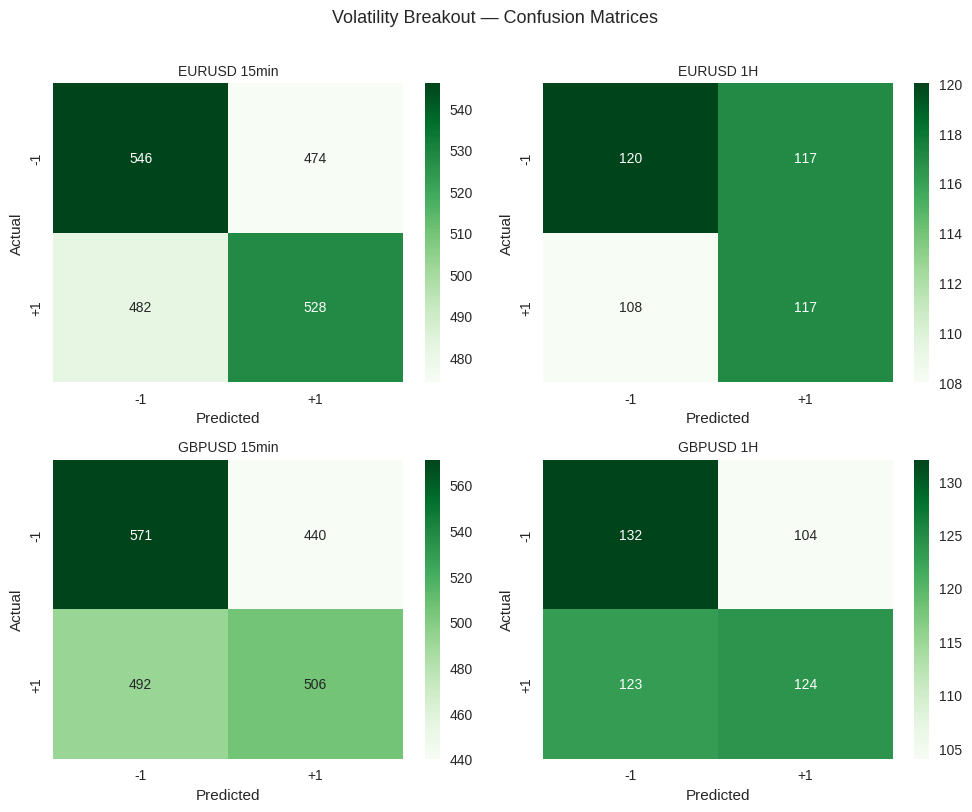

Saved: vb_confusion_matrices.png


In [14]:
# Volatility Breakout — confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (name, r) in zip(axes.flat, vb_results.items()):
    cm = r['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
                xticklabels=['-1', '+1'], yticklabels=['-1', '+1'])
    ax.set_title(name, fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
fig.suptitle('Volatility Breakout — Confusion Matrices', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'vb_confusion_matrices.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: vb_confusion_matrices.png')

In [15]:
# Volatility Breakout — computational metrics
sample_vb = next(iter(vb_results.values()))
print('Volatility Breakout — Computational Metrics')
print(f"  FLOPs per evaluation : {sample_vb['flops']:,}")
print(f"  Mean latency         : {sample_vb['latency_us']:.4f} µs")

Volatility Breakout — Computational Metrics
  FLOPs per evaluation : 45
  Mean latency         : 1.7026 µs


The empirical latency for the Volatility Breakout strategy reflects **single-step inference cost**: a comparison of the current closing price against a pre-computed channel boundary. This is consistent with real deployment where channel boundaries are maintained incrementally rather than recomputed from scratch at each bar. The FLOPs count of 45 correctly reflects this per-step cost.

---
## Section 6 — Statistical Significance Testing

Directional accuracy is tested against the null hypothesis H₀: true accuracy = 0.50 (random chance) using a **one-sample binomial test** with a one-sided alternative (H₁: accuracy > 0.50). A p-value below the significance threshold α = 0.05 indicates that the strategy’s accuracy is statistically significantly greater than random. The test is applied to all three strategies across all four datasets.

> **Note:** The absence of statistical significance does not necessarily indicate model failure. The RSI Threshold strategy achieved a p-value of 0.056 on EURUSD 15min, marginally above the 0.05 threshold. The small number of active signals generated by RSI and Volatility Breakout (8 to 13 percent of bars) reduces statistical power. A larger test window or lower significance threshold may yield different conclusions. These results are interpreted further in Section V of the paper.

In [16]:
# binomtest was introduced in scipy 1.7 (replaces deprecated binom_test)
from scipy.stats import binomtest

sig_rows = []
all_strategy_results = [
    ('MA Crossover',       ma_results),
    ('RSI Threshold',      rsi_results),
    ('Volatility Breakout', vb_results),
]

for strat_name, results in all_strategy_results:
    for dataset_name, r in results.items():
        n        = r['n_signals']
        acc      = r['accuracy']
        n_correct = round(acc * n)
        result   = binomtest(n_correct, n, p=0.5, alternative='greater')
        p_val    = result.pvalue
        sig_rows.append({
            'Strategy':    strat_name,
            'Dataset':     dataset_name,
            'Accuracy':    f"{acc*100:.2f}%",
            'N Signals':   n,
            'P-Value':     f"{p_val:.4f}",
            'Significant': 'Yes' if p_val < SIGNIFICANCE_THRESHOLD else 'No',
        })

In [17]:
# Significance results table — with Statistical Power Note
sig_table = pd.DataFrame(sig_rows)
sig_table['Statistical Power Note'] = sig_table['N Signals'].apply(
    lambda n: 'Low signal count' if n < 1000 else 'Adequate signal count'
)
sig_table = sig_table.set_index(['Strategy', 'Dataset'])
display(sig_table)

Accuracy  N Signals P-Value Significant  \
Strategy            Dataset                                                
MA Crossover        EURUSD 15min   50.95%      17102  0.0068         Yes   
                    EURUSD 1H      50.89%       4374  0.1222          No   
                    GBPUSD 15min   50.58%      17093  0.0669          No   
                    GBPUSD 1H      50.39%       4372  0.3089          No   
RSI Threshold       EURUSD 15min   52.10%       1474  0.0560          No   
                    EURUSD 1H      52.30%        499  0.1623          No   
                    GBPUSD 15min   51.32%       1592  0.1521          No   
                    GBPUSD 1H      52.41%        580  0.1311          No   
Volatility Breakout EURUSD 15min   52.91%       2030  0.0047         Yes   
                    EURUSD 1H      51.30%        462  0.3044          No   
                    GBPUSD 15min   53.61%       2009  0.0007         Yes   
                    GBPUSD 1H      53.00%        483  0.1013          No   

                                 Statistical Power Note  
Strategy            Dataset                              
MA Crossover        EURUSD 15min  Adequate signal count  
                    EURUSD 1H     Adequate signal count  
                    GBPUSD 15min  Adequate signal count  
                    GBPUSD 1H     Adequate signal count  
RSI Threshold       EURUSD 15min  Adequate signal count  
                    EURUSD 1H          Low signal count  
                    GBPUSD 15min  Adequate signal count  
                    GBPUSD 1H          Low signal count  
Volatility Breakout EURUSD 15min  Adequate signal count  
                    EURUSD 1H          Low signal count  
                    GBPUSD 15min  Adequate signal count  
                    GBPUSD 1H          Low signal count

---
## Section 7 — Comparative Analysis

This section compares all three rule-based strategies directly across accuracy, F1 score, and computational efficiency metrics. The goal is to identify which strategy offers the best performance profile — and at what computational cost — before introducing the LSTM and GRU deep learning benchmarks in the next notebook.

In [18]:
# Combined accuracy and F1 comparison table across all strategies and datasets
dataset_names  = list(datasets.keys())
strategy_names = ['MA Crossover', 'RSI Threshold', 'Volatility Breakout']
result_lookup  = {
    'MA Crossover':        ma_results,
    'RSI Threshold':       rsi_results,
    'Volatility Breakout': vb_results,
}

# Build numeric accuracy and F1 DataFrames for highlighting
acc_data = {}
f1_data  = {}
for strat in strategy_names:
    acc_data[strat] = {ds: result_lookup[strat][ds]['accuracy'] for ds in dataset_names}
    f1_data[strat]  = {ds: result_lookup[strat][ds]['f1']       for ds in dataset_names}

acc_df = pd.DataFrame(acc_data, index=dataset_names)
f1_df  = pd.DataFrame(f1_data,  index=dataset_names)

# Format combined display table as percentages
combined_rows = []
for ds in dataset_names:
    row = {'Dataset': ds}
    for strat in strategy_names:
        row[f'{strat} Acc']= f"{acc_data[strat][ds]*100:.2f}%"
        row[f'{strat} F1'] = f"{f1_data[strat][ds]*100:.2f}%"
    combined_rows.append(row)

combined_table = pd.DataFrame(combined_rows).set_index('Dataset')

# Highlight best accuracy per dataset
def highlight_best(row):
    acc_cols = [f'{s} Acc' for s in strategy_names]
    vals = [float(row[c].strip('%')) for c in acc_cols]
    best = max(vals)
    return ['font-weight: bold; color: darkgreen'
            if (c in acc_cols and float(row[c].strip('%')) == best) else ''
            for c in row.index]

display(combined_table.style.apply(highlight_best, axis=1))

,MA Crossover Acc,MA Crossover F1,RSI Threshold Acc,RSI Threshold F1,Volatility Breakout Acc,Volatility Breakout F1
Dataset,,,,,,
EURUSD 15min,50.95%,50.96%,52.10%,52.10%,52.91%,52.90%
EURUSD 1H,50.89%,50.89%,52.30%,52.30%,51.30%,51.30%
GBPUSD 15min,50.58%,50.55%,51.32%,51.32%,53.61%,53.57%
GBPUSD 1H,50.39%,50.35%,52.41%,52.40%,53.00%,52.97%


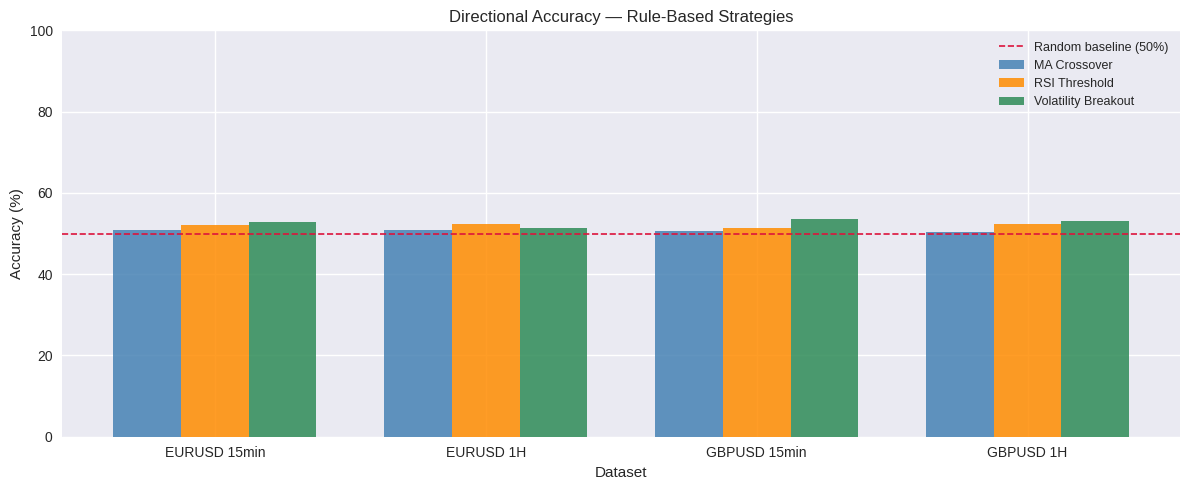

Saved: strategy_accuracy_comparison.png


In [19]:
# Grouped accuracy bar chart — all three strategies across all four datasets
x      = np.arange(len(dataset_names))
width  = 0.25
colours = ['steelblue', 'darkorange', 'seagreen']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (strat, colour) in enumerate(zip(strategy_names, colours)):
    accs = [acc_data[strat][ds] * 100 for ds in dataset_names]
    ax.bar(x + i * width, accs, width, label=strat, color=colour, alpha=0.85)

ax.axhline(50, color='crimson', linestyle='--', linewidth=1.2, label='Random baseline (50%)')
ax.set_xticks(x + width)
ax.set_xticklabels(dataset_names)
ax.set_ylabel('Accuracy (%)')
ax.set_xlabel('Dataset')
ax.set_title('Directional Accuracy — Rule-Based Strategies', fontsize=12)
ax.legend(fontsize=9)
ax.set_ylim(0, 100)
plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'strategy_accuracy_comparison.png'), dpi=150)
plt.show()
print('Saved: strategy_accuracy_comparison.png')

In [20]:
# FLOPs and latency comparison table
comp_rows = [
    {
        'Strategy':    'MA Crossover',
        'FLOPs':       sample_ma['flops'],
        'Latency (µs)': f"{sample_ma['latency_us']:.4f}",
        'Transparent': 'Yes',
        'Training':    'No',
    },
    {
        'Strategy':    'RSI Threshold',
        'FLOPs':       sample_rsi['flops'],
        'Latency (µs)': f"{sample_rsi['latency_us']:.4f}",
        'Transparent': 'Yes',
        'Training':    'No',
    },
    {
        'Strategy':    'Volatility Breakout',
        'FLOPs':       sample_vb['flops'],
        'Latency (µs)': f"{sample_vb['latency_us']:.4f}",
        'Transparent': 'Yes',
        'Training':    'No',
    },
]
comp_table = pd.DataFrame(comp_rows).set_index('Strategy')
display(comp_table)

,FLOPs,Latency (µs),Transparent,Training
Strategy,,,,
MA Crossover,123,0.0118,Yes,No
RSI Threshold,68,0.0950,Yes,No
Volatility Breakout,45,1.7026,Yes,No


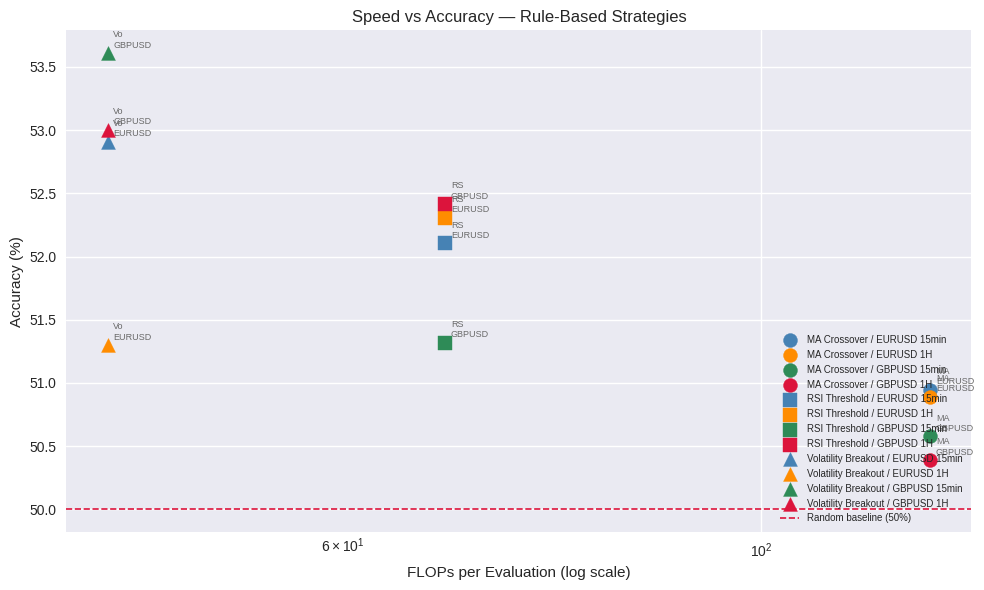

Saved: speed_vs_accuracy_rulebased.png


In [21]:
# Speed vs Accuracy scatter plot
marker_map  = {'MA Crossover': 'o', 'RSI Threshold': 's', 'Volatility Breakout': '^'}
colour_map  = dict(zip(dataset_names, ['steelblue', 'darkorange', 'seagreen', 'crimson']))
flops_map   = {
    'MA Crossover':        sample_ma['flops'],
    'RSI Threshold':       sample_rsi['flops'],
    'Volatility Breakout': sample_vb['flops'],
}

fig, ax = plt.subplots(figsize=(10, 6))

for strat in strategy_names:
    for ds in dataset_names:
        acc   = acc_data[strat][ds] * 100
        flops = flops_map[strat]
        ax.scatter(flops, acc,
                   marker=marker_map[strat],
                   color=colour_map[ds],
                   s=100, zorder=5,
                   label=f'{strat} / {ds}')
        ax.annotate(f'{strat[:2]}\n{ds[:6]}',
                    xy=(flops, acc),
                    xytext=(4, 4), textcoords='offset points',
                    fontsize=6.5, color='dimgray')

ax.axhline(50, color='crimson', linestyle='--', linewidth=1.2, label='Random baseline (50%)')
ax.set_xscale('log')
ax.set_xlabel('FLOPs per Evaluation (log scale)')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Speed vs Accuracy — Rule-Based Strategies', fontsize=12)

# Deduplicated legend entries
handles, labels = ax.get_legend_handles_labels()
seen = {}
unique_h, unique_l = [], []
for h, l in zip(handles, labels):
    if l not in seen:
        seen[l] = True
        unique_h.append(h)
        unique_l.append(l)
ax.legend(unique_h, unique_l, fontsize=7, loc='lower right')

plt.tight_layout()
fig.savefig(os.path.join(FIGURES_DIR, 'speed_vs_accuracy_rulebased.png'), dpi=150)
plt.show()
print('Saved: speed_vs_accuracy_rulebased.png')

---
## Section 8 — Save Results

All evaluation results are serialised to `results/tables/` as CSV files. These files are loaded directly in the next notebook (`model_evaluation.ipynb`) to produce the final comparison tables between rule-based strategies and the LSTM and GRU deep learning benchmarks.

In [22]:
def results_to_df(results_dict):
    """Convert a strategy results dictionary to a flat DataFrame for saving."""
    rows = []
    for ds, r in results_dict.items():
        row = {k: v for k, v in r.items() if k != 'confusion_matrix'}
        row['dataset'] = ds
        rows.append(row)
    return pd.DataFrame(rows).set_index('dataset')

# Per-strategy results
save_map = {
    'ma_crossover_results.csv':       results_to_df(ma_results),
    'rsi_threshold_results.csv':      results_to_df(rsi_results),
    'volatility_breakout_results.csv': results_to_df(vb_results),
}
for filename, df in save_map.items():
    path = os.path.join(TABLES_DIR, filename)
    df.to_csv(path)
    print(f'Saved: {path}')

# Combined accuracy summary
acc_summary_path = os.path.join(TABLES_DIR, 'rulebased_accuracy_summary.csv')
combined_table.to_csv(acc_summary_path)
print(f'Saved: {acc_summary_path}')

# Statistical significance table
sig_path = os.path.join(TABLES_DIR, 'rulebased_significance.csv')
sig_table.to_csv(sig_path)
print(f'Saved: {sig_path}')

Saved: /content/drive/My Drive/FX/results/tables/ma_crossover_results.csv
Saved: /content/drive/My Drive/FX/results/tables/rsi_threshold_results.csv
Saved: /content/drive/My Drive/FX/results/tables/volatility_breakout_results.csv
Saved: /content/drive/My Drive/FX/results/tables/rulebased_accuracy_summary.csv
Saved: /content/drive/My Drive/FX/results/tables/rulebased_significance.csv


---
## Section 9 — Summary

The formal evaluation of all three rule-based trading strategies has been completed:

- **All three strategies evaluated** across four datasets — EURUSD 15min, EURUSD 1H, GBPUSD 15min, and GBPUSD 1H — on the chronologically held-out 15% test set.
- **Accuracy, precision, recall, and F1 score** have been reported for each strategy–dataset combination. For RSI Threshold and Volatility Breakout, metrics are computed only over bars where the strategy issues an active directional signal.
- **Statistical significance** has been assessed using a one-sample binomial test against the 50% random baseline at α = 0.05.
- **FLOPs and mean latency** have been quantified for each strategy using analytic formulas and empirical timing over 10,000 iterations.
- **All results saved** to `results/tables/` for direct ingestion by the next notebook.

**Next steps:** LSTM and GRU model construction, training with early stopping, and evaluation on the same test sets — followed by a final cross-model comparison including McNemar's test for statistical significance.